# Game Interface API

A guided tour of the `Game` interface in `game.py`, the game-agnostic
contract every search algorithm in this project (MCTS, minimax,
alpha-beta pruning, depth-limited search, flat Monte Carlo) is built
against:
- `Game`: the 6-method interface any two-player, zero-sum game implements
- `TicTacToe` and `ConnectFour` (from `game_examples.py`): the two concrete
  games used throughout this project
- How those two games map onto the formal definition of a game, so the
  notation is already familiar once a search algorithm is layered on top

Parts 2-3 build intuition with `TicTacToe`, then show that `ConnectFour`
plugs into the exact same six methods, only a bigger board and a gravity
rule change.

See `README.md` for a description of every file in this directory.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

_LOG = logging.getLogger(__name__)

hdbg.init_logger(verbosity=logging.INFO)
hnotebook.config_notebook()

INFO  > /usr/local/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-f1ac349b-351a-444a-bd3b-3a89c69d9add.json


In [2]:
import random

import helpers.hintrospection as hintros
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game as rimtsaazg
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_API_utils as rimtsaazgau
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_examples as rimtsaazge

# Part 1: Library Overview

## What problem does `game.py` solve?

- Let every search algorithm (MCTS, minimax, alpha-beta pruning,
  depth-limited search, flat Monte Carlo) share one implementation instead
  of a copy per game
- Stay game-agnostic: search code only calls the 6 `Game` methods, so a new
  game plugs in without touching any search algorithm
- Give a concrete, checkable target for what "a game" means formally: the
  initial state, the actions available in a state, the result of an
  action, the goal test, and the payoff (Part 4 makes this precise)

## Mental model

| Object | Description | Type / Comments |
|--------|-------------|------------------|
| `Game` | Game-rules interface | ABC with 6 abstract methods |
| `State` | A board position | `Tuple[int, ...]`, game-specific layout |
| `Move` | An action | `int` (cell index, column, ...) |
| `TicTacToe` | 3x3 tic-tac-toe | Concrete `Game`, `game_examples.py` |
| `ConnectFour` | 7x6 Connect Four | Concrete `Game`, `game_examples.py` |

# Part 2: `Game` and `TicTacToe`

**Mental model**: `Game` is the contract between a game's rules and any
search algorithm
- anything implementing its 6 methods can be searched
- `TicTacToe` (from `game_examples.py`) is the concrete example used below.

In [3]:
# Link to the interface definition and list its abstract methods.
hintros.print_obj_info(rimtsaazg.Game)

**Game**
- `apply_move(self, state: Tuple[int, ...], move: int) -> Tuple[int, ...]`: Apply `move` to `state` and return the resulting state.
- `get_current_player(self, state: Tuple[int, ...]) -> int`: Report whose turn it is to move in `state`.
- `get_initial_state(self) -> Tuple[int, ...]`: Build the starting state of a new game.
- `get_legal_moves(self, state: Tuple[int, ...]) -> List[int]`: List the moves available from `state`.
- `get_winner(self, state: Tuple[int, ...]) -> int`: Determine the outcome of a terminal state.
- `is_terminal(self, state: Tuple[int, ...]) -> bool`: Check whether `state` ends the game.
- `render(self, state: Tuple[int, ...]) -> str`: Render `state` as a human-readable board.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/game.py#L31


## Cell 2.1: Construct a `TicTacToe` game and its initial state

In [4]:
# Link to the concrete implementation.
hintros.print_obj_info(rimtsaazge.TicTacToe)

**TicTacToe**
- `apply_move(self, state: Tuple[int, ...], move: int) -> Tuple[int, ...]`: Place the current player's mark at `move`.
- `get_current_player(self, state: Tuple[int, ...]) -> int`: Infer whose turn it is from how many cells are filled.
- `get_initial_state(self) -> Tuple[int, ...]`: Build an empty 3x3 board.
- `get_legal_moves(self, state: Tuple[int, ...]) -> List[int]`: List the empty cells, if any.
- `get_winner(self, state: Tuple[int, ...]) -> int`: Determine the outcome of a finished board.
- `is_terminal(self, state: Tuple[int, ...]) -> bool`: Check whether the board has a winner or is full.
- `render(self, state: Tuple[int, ...]) -> str`: Render the board as 3 rows of space-separated symbols.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/game_examples.py#L123


In [5]:
game = rimtsaazge.TicTacToe()
state = game.get_initial_state()
print(f"Type: {type(game)}")
# Print the internal state.
print(f"State: {state}")
# Visualize the game.
print(game.render(state))

Type: <class 'research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_examples.TicTacToe'>
State: (0, 0, 0, 0, 0, 0, 0, 0, 0)
. . .
. . .
. . .


## Cell 2.2: The `Game` methods

In [6]:
legal_moves = game.get_legal_moves(state)
print("Legal moves from the empty board:", legal_moves)

Legal moves from the empty board: [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [7]:
state = game.apply_move(state, 4)
print("After X plays the center cell:")
print(game.render(state))

After X plays the center cell:
. . .
. X .
. . .


In [8]:
print("is_terminal:", game.is_terminal(state))
print("current player to move:", game.get_current_player(state))

is_terminal: False
current player to move: -1


## Cell 2.3: A full game without search

**Goal**:
- Play a full tic-tac-toe game using only the `Game` methods
- See `X` and `O` alternate turns via `get_current_player()`
- No search involved yet: each move is picked uniformly at random

In [9]:
# TODO(gp): This can become a function like `play_random_game()`.
random.seed(0)
demo_game_state = game.get_initial_state()
first_player = game.get_current_player(demo_game_state)
print(f"The first player is: {first_player}")
cnt = 0
while not game.is_terminal(demo_game_state):
    cnt += 1
    # Find the legal moves.
    legal_moves = game.get_legal_moves(demo_game_state)
    current_player = game.get_current_player(demo_game_state)
    # Pick a move at random.
    move = random.choice(legal_moves)
    demo_game_state = game.apply_move(demo_game_state, move)
    print(
        f"\nAfter move #{cnt}: {move} by {current_player}, state:\n{game.render(demo_game_state)}"
    )
winner = game.get_winner(demo_game_state)
print("\nwinner:", winner)

The first player is: 1

After move #1: 6 by 1, state:
. . .
. . .
X . .

After move #2: 7 by -1, state:
. . .
. . .
X O .

After move #3: 0 by 1, state:
X . .
. . .
X O .

After move #4: 3 by -1, state:
X . .
O . .
X O .

After move #5: 8 by 1, state:
X . .
O . .
X O X

After move #6: 5 by -1, state:
X . .
O . O
X O X

After move #7: 2 by 1, state:
X . X
O . O
X O X

After move #8: 4 by -1, state:
X . X
O O O
X O X

winner: -1


## Cell 2.4: Play tic-tac-toe yourself

**Goal**:
- Play both `X` and `O` by clicking cells, using the same `Game` methods
  as Cell 2.3, this time driven by mouse clicks instead of `random.choice()`

In [10]:
rimtsaazgau.cell2_4_build_play_widget(game)

# Part 3: Connect Four

**Mental model**:
- the same `Game` interface works unchanged against `ConnectFour`
- What changes is only the board: 42 cells instead of 9, and a move is a column
(the disc drops to the lowest empty row: gravity), not a free choice of cell.

## Cell 3.1: Construct a `ConnectFour` game and picture its initial board

In [11]:
# Link to the concrete implementation.
hintros.print_obj_info(rimtsaazge.ConnectFour)

**ConnectFour**
- `apply_move(self, state: Tuple[int, ...], move: int) -> Tuple[int, ...]`: Drop the current player's mark into column `move`.
- `get_current_player(self, state: Tuple[int, ...]) -> int`: Infer whose turn it is from how many cells are filled.
- `get_initial_state(self) -> Tuple[int, ...]`: Build an empty 6x7 board.
- `get_legal_moves(self, state: Tuple[int, ...]) -> List[int]`: List the columns that still have room, if any.
- `get_winner(self, state: Tuple[int, ...]) -> int`: Determine the outcome of a finished board.
- `is_terminal(self, state: Tuple[int, ...]) -> bool`: Check whether the board has a 4-in-a-row winner or is full.
- `render(self, state: Tuple[int, ...]) -> str`: Render the board as 6 rows of space-separated symbols.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/game_examples.py#L322


Type: <class 'research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_examples.ConnectFour'>
State length: 42
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .


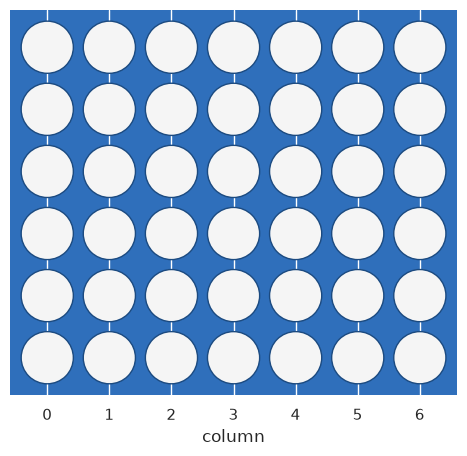

In [12]:
connect_four = rimtsaazge.ConnectFour()
cf_state = connect_four.get_initial_state()
print(f"Type: {type(connect_four)}")
print(f"State length: {len(cf_state)}")
# A picture reads a Connect Four position far faster than the text grid
# `render()` produces below it.
print(connect_four.render(cf_state))
rimtsaazgau.plot_connect_four_board(cf_state)

## Cell 3.2: The `Game` methods on Connect Four

Same six methods as `TicTacToe` in Part 2, this time a move is a column
and gravity decides which cell it actually fills.

In [13]:
legal_moves = connect_four.get_legal_moves(cf_state)
print("Legal moves from the empty board (columns):", legal_moves)

Legal moves from the empty board (columns): [0, 1, 2, 3, 4, 5, 6]


After red then yellow both drop into column 3 (gravity stacks them):


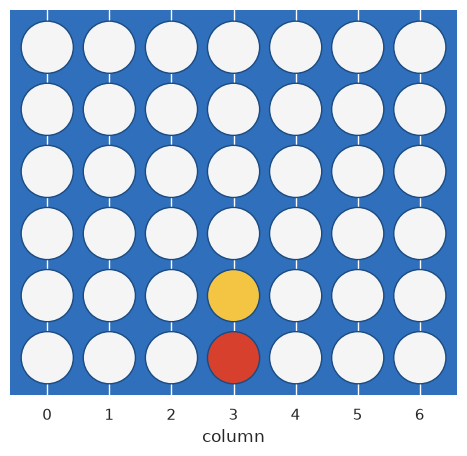

In [14]:
cf_state = connect_four.apply_move(cf_state, 3)
cf_state = connect_four.apply_move(cf_state, 3)
print("After red then yellow both drop into column 3 (gravity stacks them):")
rimtsaazgau.plot_connect_four_board(cf_state)

In [15]:
print("is_terminal:", connect_four.is_terminal(cf_state))
print("current player to move:", connect_four.get_current_player(cf_state))

is_terminal: False
current player to move: 1


## Cell 3.3: Play Connect Four yourself

**Goal**:
- Play both red and yellow by clicking a column

In [16]:
rimtsaazgau.cell3_3_build_connect_four_play_widget(connect_four)

**Key observations**:
- The disc always lands on top of the stack in its column: `apply_move()`
  never lets you choose the row directly, unlike tic-tac-toe

# Part 4: Framing the game as a search problem

**Goal**: before any search algorithm touches `TicTacToe` or
`ConnectFour`, pin down what "searching a game" formally means, using
only the `Game` methods already introduced in Parts 2-3.

## Cell 4.1: The five components of a game

A two-player, zero-sum, perfect-information game is defined by five
components, each with a direct counterpart in `Game`:

| Component | Notation | `Game` method |
|-----------|----------|----------------|
| Initial state | $s_0$ | `get_initial_state()` |
| Actions | $Actions(s)$ | `get_legal_moves(s)` |
| Transition model | $Result(s, a)$ | `apply_move(s, a)` |
| Goal test | $IsTerminal(s)$ | `is_terminal(s)` |
| Utility | $Utility(s, p)$ | `get_winner(s)` |

`get_current_player(s)` adds one more piece needed once an opponent enters
the picture: $Player(s)$, whose turn it is to move in $s$.

In [17]:
s0 = game.get_initial_state()
print("s0 =", s0)
print("Actions(s0) =", game.get_legal_moves(s0))

s0 = (0, 0, 0, 0, 0, 0, 0, 0, 0)
Actions(s0) = [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [18]:
a = 4
result = game.apply_move(s0, a)
print(f"Result(s0, {a}) =", result)
print("IsTerminal(Result(s0, 4)) =", game.is_terminal(result))

Result(s0, 4) = (0, 0, 0, 0, 1, 0, 0, 0, 0)
IsTerminal(Result(s0, 4)) = False


In [19]:
# A near-finished board makes Utility concrete: X already has two in a row,
# so playing cell 2 reaches a terminal state with a definite payoff.
demo_state = (1, 1, 0, -1, -1, 0, 0, 0, 0)
print(game.render(demo_state))
print("IsTerminal(s) =", game.is_terminal(demo_state))

X X .
O O .
. . .
IsTerminal(s) = False


In [20]:
terminal_state = game.apply_move(demo_state, 2)
print(game.render(terminal_state))
print("IsTerminal(s) =", game.is_terminal(terminal_state))
print("Utility(s, Max) =", game.get_winner(terminal_state))

X X X
O O .
. . .
IsTerminal(s) = True
Utility(s, Max) = 1


**Key observations**:
- `get_winner()` already returns the payoff from $Max$'s point of view
  (`1`/`-1`/`0`), matching the zero-sum convention
  $Utility(s, Max) + Utility(s, Min) = 0$
- Every `Game` implementation, `TicTacToe` and `ConnectFour` alike, is
  defined entirely by these five components: no search algorithm has been
  used yet, only the rules

## Cell 4.2: Naming the tree: an AND-OR tree

Once a second player enters the picture, the tree of reachable states is
not a plain search tree: it is an **AND-OR tree**.
- At an `OR` node, the agent to move chooses: one good child is enough
- At an `AND` node, the opponent chooses: every child must be handled,
  since the agent cannot control which one the opponent picks

For an adversarial game the two players give the two node kinds their
names:
- $Max$'s turns are `OR` nodes (`Player(s) == Max` picks freely between
$Actions(s)$)
- $Min$'s turns are `AND` nodes (whatever $Min$ picks, $Max$ must have an answer
ready for it).

In [21]:
print("Player(s0) =", game.get_current_player(s0), "-> Max's turn, an OR node")
after_x = game.apply_move(s0, 4)
print(game.render(after_x))
print(
    "Player(Result(s0, 4)) =",
    game.get_current_player(after_x),
    "-> Min's turn, an AND node",
)

Player(s0) = 1 -> Max's turn, an OR node
. . .
. X .
. . .
Player(Result(s0, 4)) = -1 -> Min's turn, an AND node


**Key observations**:
- `get_current_player()` alone tells `OR` nodes from `AND` nodes
    - `Max` layers alternate with `Min` layers at every ply, for both
    `TicTacToe` and `ConnectFour`
- A solution to an AND-OR tree is a **subtree**, not a single path:
    - one kept branch at every `OR` node
    - every branch kept at every `AND` node, since $Max$ must survive any reply $Min$ chooses
- This is exactly the shape the next notebook's search algorithms
  (starting with Minimax) compute over: `Actions`, `Result`, `IsTerminal`,
  and `Utility` are unchanged, only the algorithm walking the tree differs